In [25]:
import pandas as pd
from pathlib import Path
import numpy as np
from common.consts import proteins, thresholds, res_colors
from common.colvar_utils import load_colvar

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
# import numpy as np
# import pandas as pd
# from pathlib import Path
# from common.colvar_utils import load_colvar

# all_mfpt = {protein: {th: [] for th in thresholds} for protein in proteins}

# required_cols = ["time", "metad.acc", "rmsd"]

# def read_colvar_with_fields(path):
#     return load_colvar(path, usecols=required_cols, nrows=None)

# for protein in proteins:
#     base_path = Path(f"../data/{protein}/output")
#     print(protein)
#     for i in range(9000, 9200):
#         index_str = f"{i:03}"
#         candidates = [
#             base_path / f"run_{index_str}" / f"HLDA_COLVAR_{index_str}",
#             base_path / f"run_{index_str}" / f"COLVAR_{index_str}",
#         ]
#         run_path = next((p for p in candidates if p.exists()), None)
#         if run_path is None:
#             print(f"Missing: {candidates[0]} and {candidates[1]}")
#             continue

#         try:
#             df = read_colvar_with_fields(run_path)
#         except FileNotFoundError:
#             print(f"Missing: {run_path}")
#             continue

#         missing_cols = [c for c in required_cols if c not in df.columns]
#         if missing_cols:
#             print(f"Missing required columns in {run_path}: {missing_cols}")
#             continue

#         passed = set()
#         for _, row in df.iterrows():
#             time = row["time"]
#             acc = row["metad.acc"]
#             rmsd = row["rmsd"]
#             predicted = time * acc
#             for th in thresholds:
#                 if th not in passed and rmsd > th:
#                     all_mfpt[protein][th].append(predicted)
#                     passed.add(th)
#             if len(passed) == len(thresholds):
#                 break


In [27]:
# import pickle

# with open("../data/mfpt-pace=25000-new-ref.pkl", "wb") as f:
#     pickle.dump(all_mfpt, f)


0.28
WT: 0.0982 us, extra: 27
D2A: 0.03096 us, extra: 16
D2C: 0.0592 us, extra: 26
D2M: 0.04023 us, extra: 33
D2N: 0.03011 us, extra: 25
D2R: 0.01447 us, extra: 49
D2E: 0.0619 us, extra: 17
D2Y: 0.04314 us, extra: 53
Y9E: 0.004697 us, extra: 25
Y9G: 0.004241 us, extra: 45
Y9Q: 0.00419 us, extra: 53
Y9R: 0.00597 us, extra: 25
Y9V: 0.01177 us, extra: 33
Y9A: 0.001934 us, extra: 41
T7V: 0.06774 us, extra: 15
T7Q: 0.008936 us, extra: 21
T7R: 0.5163 us, extra: 31
T7Y: 0.01235 us, extra: 15
T7G: 0.0002744 us, extra: 41
T7D: 0.1064 us, extra: 17
Y0R: 0.007282 us, extra: 50
Y0Q: 0.02803 us, extra: 49
Y0E: 0.02239 us, extra: 26
Y0A: 0.05346 us, extra: 29
P3M: 0.07299 us, extra: 16
P3D: 0.003307 us, extra: 18
P3R: 0.00465 us, extra: 119
P3C: 0.005958 us, extra: 28
T5R: 7.409 us, extra: 30
T5G: 1.087 us, extra: 26
T5Y: 0.003083 us, extra: 75
T5D: 0.01058 us, extra: 69
E4A: 0.005769 us, extra: 28
E4G: 0.1115 us, extra: 89
E4R: 0.004975 us, extra: 33
E4Y: 0.005393 us, extra: 99
D2K: 0.01477 us, ext

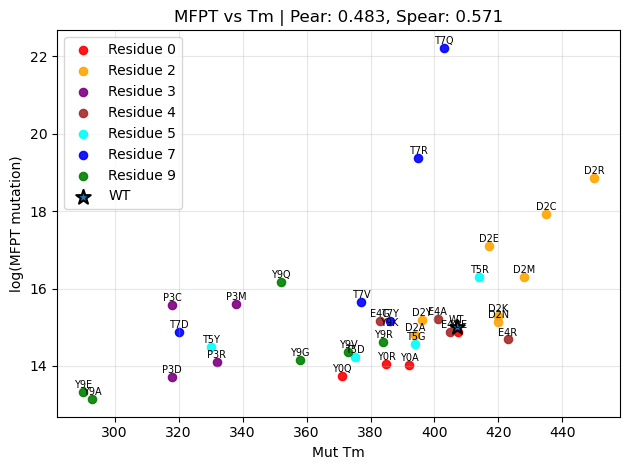

p: 0.08421538514061717


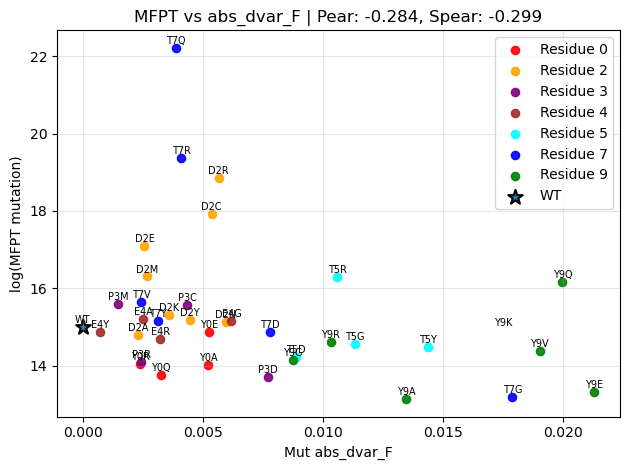

(np.float64(-0.2838017291014166), np.float64(-0.2990480358901412))

In [28]:

import os
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from common.utils import collect_df
from common.hlda_utils import load_lambda_grid

def plot_mfpt_corr(df, prop_col, wt_label='WT', group_col='residue_idx',
                   annotate=False, th=None, log_prop=True):
    x_series = pd.to_numeric(df[prop_col], errors='coerce')
    y_series = pd.to_numeric(df['mfpt'], errors='coerce')

    y_log = np.log(y_series)
    valid_mask = x_series.notna() & y_log.replace([np.inf, -np.inf], np.nan).notna()

    x_all = x_series[valid_mask].to_numpy()
    y_all = y_log[valid_mask].to_numpy()
    names = df.index[valid_mask].to_numpy()

    x_map = x_series
    y_map = y_log

    if len(x_all) >= 2 and np.nanstd(x_all) > 0 and np.nanstd(y_all) > 0:
        pearson, p = stats.pearsonr(x_all, y_all)
    else:
        pearson, p = np.nan, np.nan

    if len(x_all) >= 2 and np.nanstd(y_all) > 0:
        spearman, _ = stats.spearmanr(x_all, y_all)
    else:
        spearman = np.nan

    print(f"p: {p}")

    for k in sorted(int(k) for k in df[group_col].dropna().unique()):
        sub_idx = df.index[df[group_col] == k]
        sub_mask = sub_idx.intersection(df.index[valid_mask])
        if len(sub_mask) == 0:
            continue
        plt.scatter(
            x_map.loc[sub_mask].to_numpy(),
            y_map.loc[sub_mask].to_numpy(),
            label=f"Residue {k}", s=35, alpha=0.9, c=res_colors.get(k)
        )

    wt_prop = x_map.get(wt_label, np.nan)
    wt_y = y_map.get(wt_label, np.nan)
    if np.isfinite(wt_prop) and np.isfinite(wt_y):
        plt.scatter(wt_prop, wt_y, s=120, marker='*', edgecolors='k', linewidths=1.5, label=wt_label)

    if annotate:
        for xv, yv, name in zip(x_all, y_all, names):
            if np.isfinite(xv) and np.isfinite(yv):
                plt.text(xv, yv + 0.05, name, fontsize=7, ha='center', va='bottom')

    xlabel = (f"Mut {prop_col}" if log_prop and not pd.isna(wt_prop) else prop_col)
    plt.xlabel(xlabel)
    plt.ylabel('log(MFPT mutation)')
    t = f" | Th={th:.3g}" if th is not None else ""
    pear_txt = "nan" if np.isnan(pearson) else f"{pearson:.3g}"
    spear_txt = "nan" if np.isnan(spearman) else f"{spearman:.3g}"
    plt.title(f"MFPT vs {prop_col}{t} | Pear: {pear_txt}, Spear: {spear_txt}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pearson, spearman


with open("../data/mfpt-pace=25000-new-ref.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

os.makedirs("../data", exist_ok=True)

thresholds = np.array(list(all_mfpt['WT'].keys()))
tF = 0.25
tU = 0.68
skip_short = set()
lambda_grid = load_lambda_grid(cache_path="../data/hlda_lambda_grid.pkl", base_dir="../data/traj")

all_tables = {}

for t in thresholds:
    print(t)
    df = collect_df(
        all_mfpt,
        mfpt_threshold=float(t),
        tF=tF,
        tU=tU,
        skip_short=skip_short,
        lambda_df=lambda_grid,
        quiet=False,
    )
    all_tables[t] = df  # store the full dataframe

# Save to one pickle file
out_path = "../data/mfpt_all_thresholds-new-ref.pkl"
with open(out_path, "wb") as f:
    pickle.dump(all_tables, f)

print(f"Saved all thresholds into {out_path}")
# plot_mfpt_corr(df, 'enthalpy', annotate=True)
plot_mfpt_corr(df, 'Tm', annotate=True)
plot_mfpt_corr(df, 'abs_dvar_F', annotate=True)


0.32
545509.114022954 40


KeyError: 'WT'

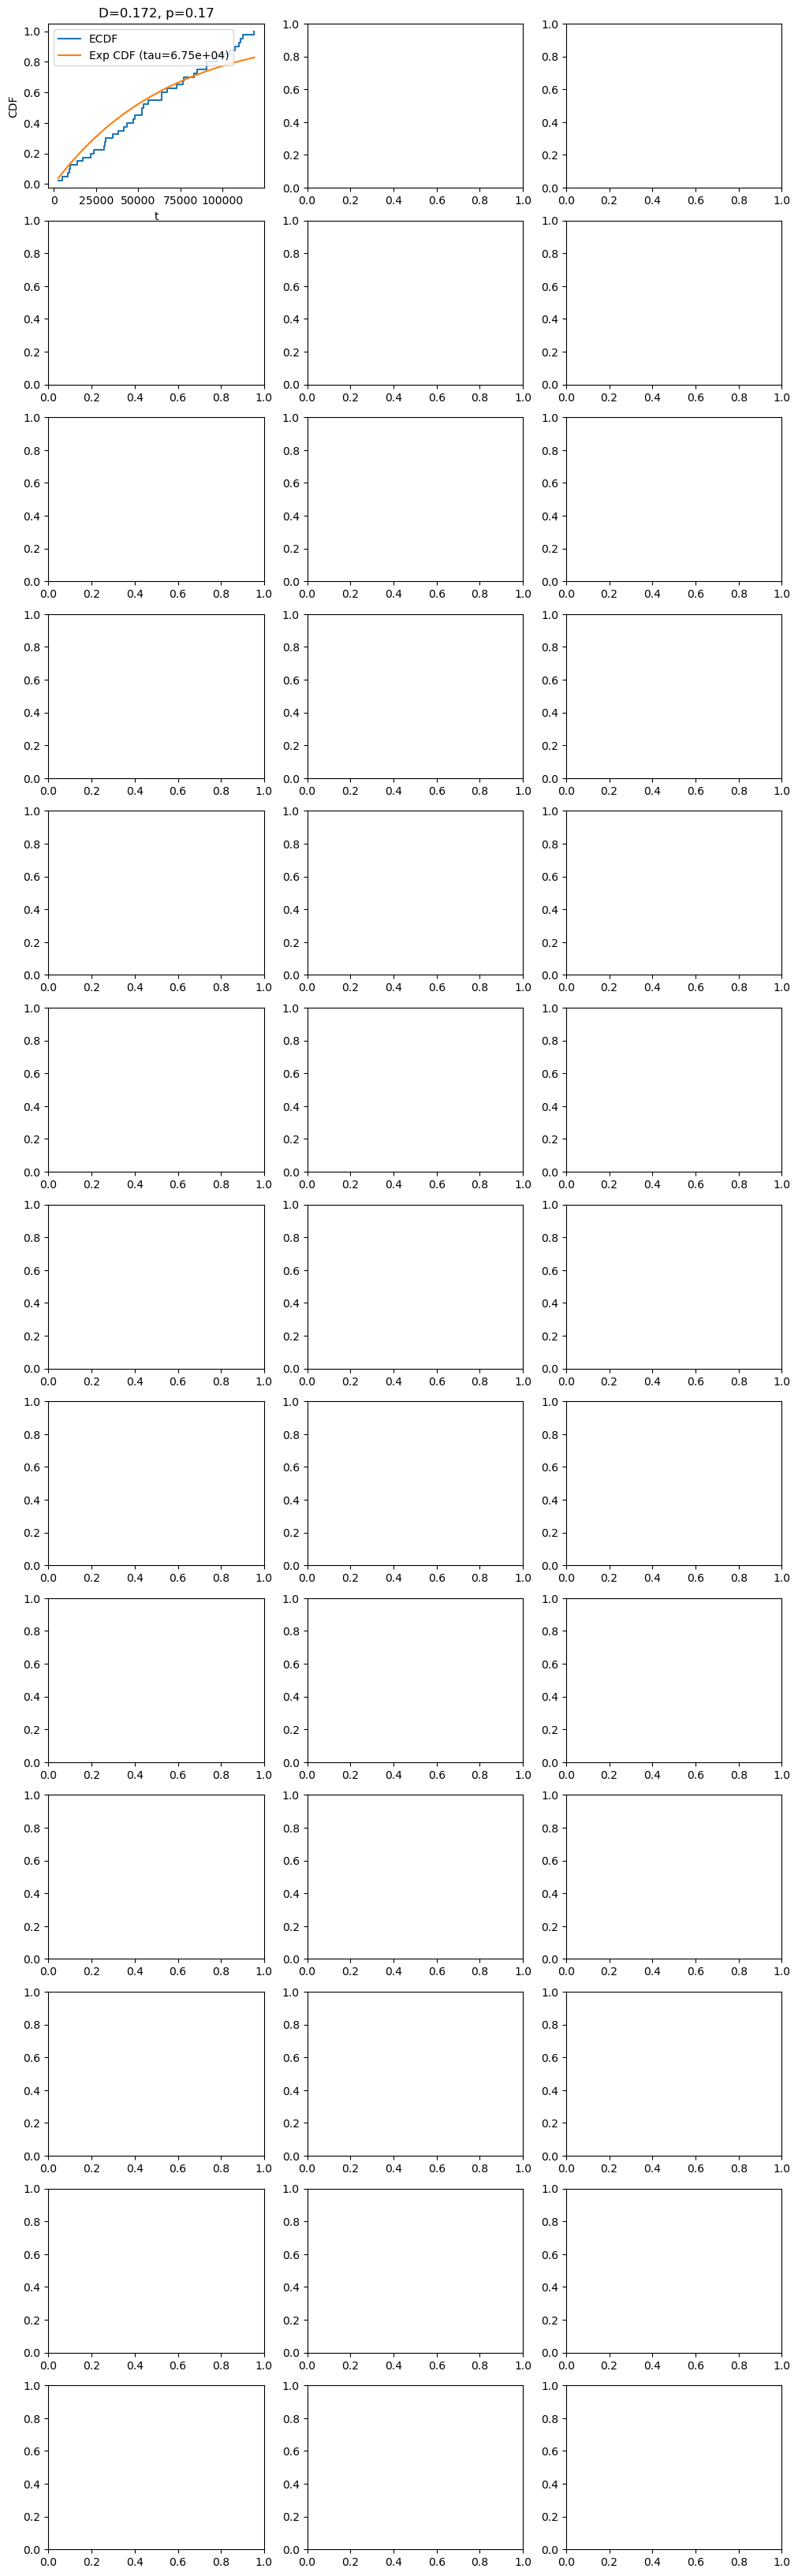

In [29]:
import math

from scipy import optimize 
from common.consts import long_to_short
from common.utils import estimateMFPT, fit_exp_ks

def fit_exp_ecdf(samples, ax):
    x = np.array(samples)

    n = x.size
    def F(t, tau): return 1 - np.exp(-t / tau)
    ecdf = np.arange(1, n + 1) / n
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    th = stats.expon.cdf(x, scale=tau)

    ax.step(x, ecdf, where="post", label="ECDF")
    ax.plot(x, th, label=f"Exp CDF (tau={tau:.3g})")
    D, p = stats.kstest(x, "expon", args=(0, tau))
    ax.set_xlabel("t"); ax.set_ylabel("CDF"); ax.legend(); ax.set_title(f"D={D:.3g}, p={p:.2g}")
    return tau, D, p, ax

def ks_table_fastest_k(all_mfpt, names, th, k):
    rows = []
    for name in names:
        s = np.array(all_mfpt[name][th])
        s.sort()
        
        s = s[:k]
        tau, p, D = fit_exp_ks(s)
        rows.append({"name": name, "n": s.size, "tau": tau, "ks_p": p, "ks_D": D})
    return pd.DataFrame(rows).sort_values("ks_p", ascending=False)

def plot_ecdfs_grid_fastest_k(all_mfpt, names, th, k = None ):
    ncols=3
    m = len(names)
    nrows = math.ceil(m / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows), squeeze=False)
    for i, name in enumerate(names):
        r, c = divmod(i, ncols)
        if k == None:
            mfpt_base, k = estimateMFPT(np.array(all_mfpt[name][th]), 10)
            print(mfpt_base, k)

        s = np.sort(np.array(all_mfpt[name][th]))[:k]
        fit_exp_ecdf(s, ax=axes[r, c])
        axes[r, c].set_title(f"{long_to_short[name]} | " + axes[r, c].get_title())
        
    fig.tight_layout()
    return fig

th = np.array(list(all_mfpt['WT'].keys()))[2]
print(th)
names = list(proteins)
k = 25
# res = ks_table_fastest_k(all_mfpt, names, th, k = k)

plot_ecdfs_grid_fastest_k(all_mfpt, names, th)
plt.show()

# plot_ecdfs_grid_fastest_k(all_mfpt, names, th, k = k)
# plt.show()

def compare_k_vs_dynamic(all_mfpt, names, th, k = k):
    rows = []
    for name in names:
        s_all = np.sort(np.array(all_mfpt[name][th]))

        s_fixed = s_all[:k]
        fig, ax = plt.subplots()
        tau_f, D_f, p_f, _ = fit_exp_ecdf(s_fixed, ax=ax)
        plt.close(fig)

        # Dynamic k from estimateMFPT
        _, k_dyn = estimateMFPT(s_all, 10)
        s_dyn = s_all[:k_dyn]
        fig, ax = plt.subplots()
        tau_d, D_d, p_d, _ = fit_exp_ecdf(s_dyn, ax=ax)
        plt.close(fig)

        rows.append({
            "name": name,
            "k_fixed": k, "tau_fixed": tau_f, "D_fixed": D_f, "p_fixed": p_f,
            "k_dyn": k_dyn, "tau_dyn": tau_d, "D_dyn": D_d, "p_dyn": p_d
        })

    df = pd.DataFrame(rows)
    print(df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].scatter(df["D_fixed"], df["D_dyn"])
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_xlabel(f"D (k={k})")
    axes[0].set_ylabel("D (dynamic k)")
    axes[0].set_title("KS D comparison")

    axes[1].scatter(df["p_fixed"], df["p_dyn"])
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel(f"p-value (k={k})")
    axes[1].set_ylabel("p-value (dynamic k)")
    axes[1].set_title("KS p-value comparison")

    fig.tight_layout()
    return df, fig

# df_comparison, fig_cmp = compare_k_vs_dynamic(all_mfpt, names, th)
# plt.show()


In [ ]:
# %load_ext autoreload
# %autoreload 2

# from pathlib import Path
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import optimize, stats
# from common.utils import estimateMFPT
# import warnings

# warnings.filterwarnings("ignore", category=FutureWarning)

# PROTEINS = ['D2A','D2C','T7Q', 'T7R']
# RANGES = [(4000, 4200), (3000, 3200), (3201, 3400)]
# THRESHOLDS = np.round(np.arange(0.1, 0.5 + 1e-9, 0.05), 2)

# def read_colvar(path: Path) -> pd.DataFrame:
#     with path.open() as f:
#         for line in f:
#             if line.startswith("#! FIELDS"):
#                 names = line.replace("#! FIELDS", "").strip().split()
#                 break
#         else:
#             raise ValueError(f"No FIELDS header in {path}")
#     return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

# def first_cross_times(df: pd.DataFrame, thresholds):
#     rmsd = df['rmsd'].to_numpy()
#     t = df['time'].to_numpy()
#     acc = df['metad.acc'].to_numpy()
#     out = {}
#     for th in thresholds:
#         idx = np.flatnonzero(rmsd > th)
#         out[float(th)] = None if idx.size == 0 else float(t[idx[0]] * acc[idx[0]])
#     return out

# def fit_tau_and_pvalue(samples):
#     x = np.array(sorted(samples, key=float))
#     n = len(x)
#     ecdf = np.arange(1, n + 1) / n
#     tau = optimize.curve_fit(lambda tt, tau: 1 - np.exp(-tt / tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
#     f = np.random.exponential(tau, size=max(10000, 10*n))
#     p = stats.ks_2samp(x, f, alternative="two-sided", method="asymp")[1]
#     return tau, p

# def gather_samples_multi(protein: str, start: int, stop: int, thresholds):
#     base = Path(f"../data/{protein}/output")
#     buckets = {float(th): [] for th in thresholds}
#     for i in range(start, stop):
#         p = base / f"run_{i}" / f"HLDA_COLVAR_{i}"
#         if not p.exists():
#             print(f"Missing file: {p}")
#             continue
#         df = read_colvar(p)
#         crosses = first_cross_times(df, thresholds)
#         for th, val in crosses.items():
#             if val is not None:
#                 buckets[th].append(val)
#     rows = []
#     for th, arr in buckets.items():
#         if not arr:
#             rows.append(dict(thresh=th, mfpt=None, k=None, pvalue=None, n=0))
#             continue
#         arr = np.array(arr, float)
#         mfpt, k = estimateMFPT(arr, 15)
#         tau, pval = fit_tau_and_pvalue(arr)
#         rows.append(dict(thresh=th, mfpt=mfpt, k=k, pvalue=pval, n=len(arr)))
#     return pd.DataFrame(rows)

# all_rows = []
# for protein in PROTEINS:
#     for (a, b) in RANGES:
#         res = gather_samples_multi(protein, a, b, THRESHOLDS)
#         res['protein'] = protein
#         res['start'] = a
#         res['stop'] = b
#         all_rows.append(res)

# res = pd.concat(all_rows, ignore_index=True)
# print(res)

# fig1, axes1 = plt.subplots(len(PROTEINS), 1, figsize=(6, 4*len(PROTEINS)), squeeze=False)
# for ax, protein in zip(axes1.ravel(), PROTEINS):
#     sub = res[(res.protein==protein) & res.mfpt.notna()]
#     for (a,b), g in sub.groupby(["start","stop"]):
#         g = g.sort_values("thresh")
#         ax.plot(g.thresh, g.mfpt*1e-6, marker="o", label=f"{a}-{b-1}")
#     ax.set_title(f"{protein} — MFPT vs threshold")
#     ax.set_xlabel("threshold")
#     ax.set_ylabel("MFPT (µs)")
#     ax.legend()
# plt.tight_layout()
# plt.show()

# fig2, axes2 = plt.subplots(len(PROTEINS), 1, figsize=(6, 4*len(PROTEINS)), squeeze=False)
# for ax, protein in zip(axes2.ravel(), PROTEINS):
#     sub = res[(res.protein==protein) & res.pvalue.notna()]
#     for (a,b), g in sub.groupby(["start","stop"]):
#         g = g.sort_values("thresh")
#         ax.plot(g.thresh, g.pvalue, marker="s", label=f"{a}-{b-1}")
#     ax.set_title(f"{protein} — KS p-value vs threshold")
#     ax.set_xlabel("threshold")
#     ax.set_ylabel("p-value")
#     ax.legend()
# plt.tight_layout()
# plt.show()
